In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from functools import reduce

# 시각화 폰트 설정 (Windows 기준)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


In [2]:
# data_sleep 폴더의 모든 .xpt 데이터 파일 임포트
sleep_data_path = 'data_sleep'
sleep_files = [f for f in os.listdir(sleep_data_path) if f.endswith('.xpt')]

sleep_dfs = {}
for file in sleep_files:
    file_path = os.path.join(sleep_data_path, file)
    # 확장자를 제외한 파일명을 키로 하여 데이터프레임 저장
    name = os.path.splitext(file)[0]
    try:
        sleep_dfs[name] = pd.read_sas(file_path, format='xport')
        print(f"Successfully loaded: {file}")
    except Exception as e:
        print(f"Error loading {file}: {e}")

print(f"\n총 {len(sleep_dfs)}개의 수면 데이터 파일을 로드했습니다.")

Successfully loaded: DEMO_D.xpt
Successfully loaded: DEMO_E.xpt
Successfully loaded: DEMO_F.xpt
Successfully loaded: DEMO_G.xpt
Successfully loaded: DEMO_H.xpt
Successfully loaded: DEMO_I.xpt
Successfully loaded: DEMO_J.xpt
Successfully loaded: DEMO_L.xpt
Successfully loaded: P_DEMO.xpt
Successfully loaded: P_SLQ.xpt
Successfully loaded: SLQ_D.xpt
Successfully loaded: SLQ_E.xpt
Successfully loaded: SLQ_F.xpt
Successfully loaded: SLQ_G.xpt
Successfully loaded: SLQ_H.xpt
Successfully loaded: SLQ_I.xpt
Successfully loaded: SLQ_J.xpt
Successfully loaded: SLQ_L.xpt

총 18개의 수면 데이터 파일을 로드했습니다.


In [3]:
# 각 주기(D, E, F, G, H, I, J, L, P)별로 DEMO와 SLQ 데이터를 조인하여 9개의 테이블 생성
cycles = ['D', 'E', 'F', 'G', 'H', 'I', 'J', 'L', 'P']
combined_dfs = {}

for cycle in cycles:
    if cycle == 'P':
        demo_key = 'P_DEMO'
        slq_key = 'P_SLQ'
    else:
        demo_key = f'DEMO_{cycle}'
        slq_key = f'SLQ_{cycle}'
    
    if demo_key in sleep_dfs and slq_key in sleep_dfs:
        # SEQN을 기준으로 Inner Join 실행
        combined_dfs[cycle] = pd.merge(sleep_dfs[demo_key], sleep_dfs[slq_key], on='SEQN', how='inner')
        print(f"주기 {cycle}: {demo_key} 와 {slq_key} 조인 완료. 행/열: {combined_dfs[cycle].shape}")
    else:
        missing = []
        if demo_key not in sleep_dfs: missing.append(demo_key)
        if slq_key not in sleep_dfs: missing.append(slq_key)
        print(f"주기 {cycle}: 데이터를 찾을 수 없습니다. (누락: {', '.join(missing)})")

print(f"\n총 {len(combined_dfs)}개의 통합 테이블이 생성되었습니다.")

주기 D: DEMO_D 와 SLQ_D 조인 완료. 행/열: (6139, 70)
주기 E: DEMO_E 와 SLQ_E 조인 완료. 행/열: (6546, 70)
주기 F: DEMO_F 와 SLQ_F 조인 완료. 행/열: (6889, 46)
주기 G: DEMO_G 와 SLQ_G 조인 완료. 행/열: (6175, 51)
주기 H: DEMO_H 와 SLQ_H 조인 완료. 행/열: (6464, 50)
주기 I: DEMO_I 와 SLQ_I 조인 완료. 행/열: (6327, 54)
주기 J: DEMO_J 와 SLQ_J 조인 완료. 행/열: (6161, 56)
주기 L: DEMO_L 와 SLQ_L 조인 완료. 행/열: (8501, 33)
주기 P: P_DEMO 와 P_SLQ 조인 완료. 행/열: (10195, 39)

총 9개의 통합 테이블이 생성되었습니다.


In [4]:
# 생성된 모든 주기별 테이블을 하나로 수직 통합 (pd.concat)
final_list = []

for cycle, df in combined_dfs.items():
    # 데이터의 출처(주기)를 나타내는 컬럼 추가
    df = df.copy() # 원본 보존을 위해 카피본 사용
    df['CYCLE'] = cycle
    final_list.append(df)

# 모든 데이터프레임을 하나로 합침
sleep_final_df = pd.concat(final_list, axis=0, ignore_index=True)

print(f"최종 통합 완료! 전체 데이터 행/열: {sleep_final_df.shape}")
print(f"주기별 데이터 분포:\n{sleep_final_df['CYCLE'].value_counts().sort_index()}")

# 상위 5개 데이터 확인
sleep_final_df.head()

최종 통합 완료! 전체 데이터 행/열: (63397, 101)
주기별 데이터 분포:
CYCLE
D     6139
E     6546
F     6889
G     6175
H     6464
I     6327
J     6161
L     8501
P    10195
Name: count, dtype: int64


,SEQN,SDDSRVYR,RIDSTATR,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,DMQMILIT,...,DMDHRMAZ,DMDHSEDZ,SLQ320,SLQ330,SLD013,DMDYRUSR,DMDMARTZ,DMDYRUSZ,WTINTPRP,WTMECPRP
0,31130.0,4.0,2.0,2.0,2.0,85.0,NaN,NaN,3.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,31131.0,4.0,2.0,2.0,2.0,44.0,535.0,536.0,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,31132.0,4.0,2.0,2.0,1.0,70.0,842.0,843.0,3.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,31133.0,4.0,2.0,2.0,2.0,16.0,193.0,194.0,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,31134.0,4.0,2.0,2.0,1.0,73.0,882.0,883.0,3.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 수면 변동성 분포

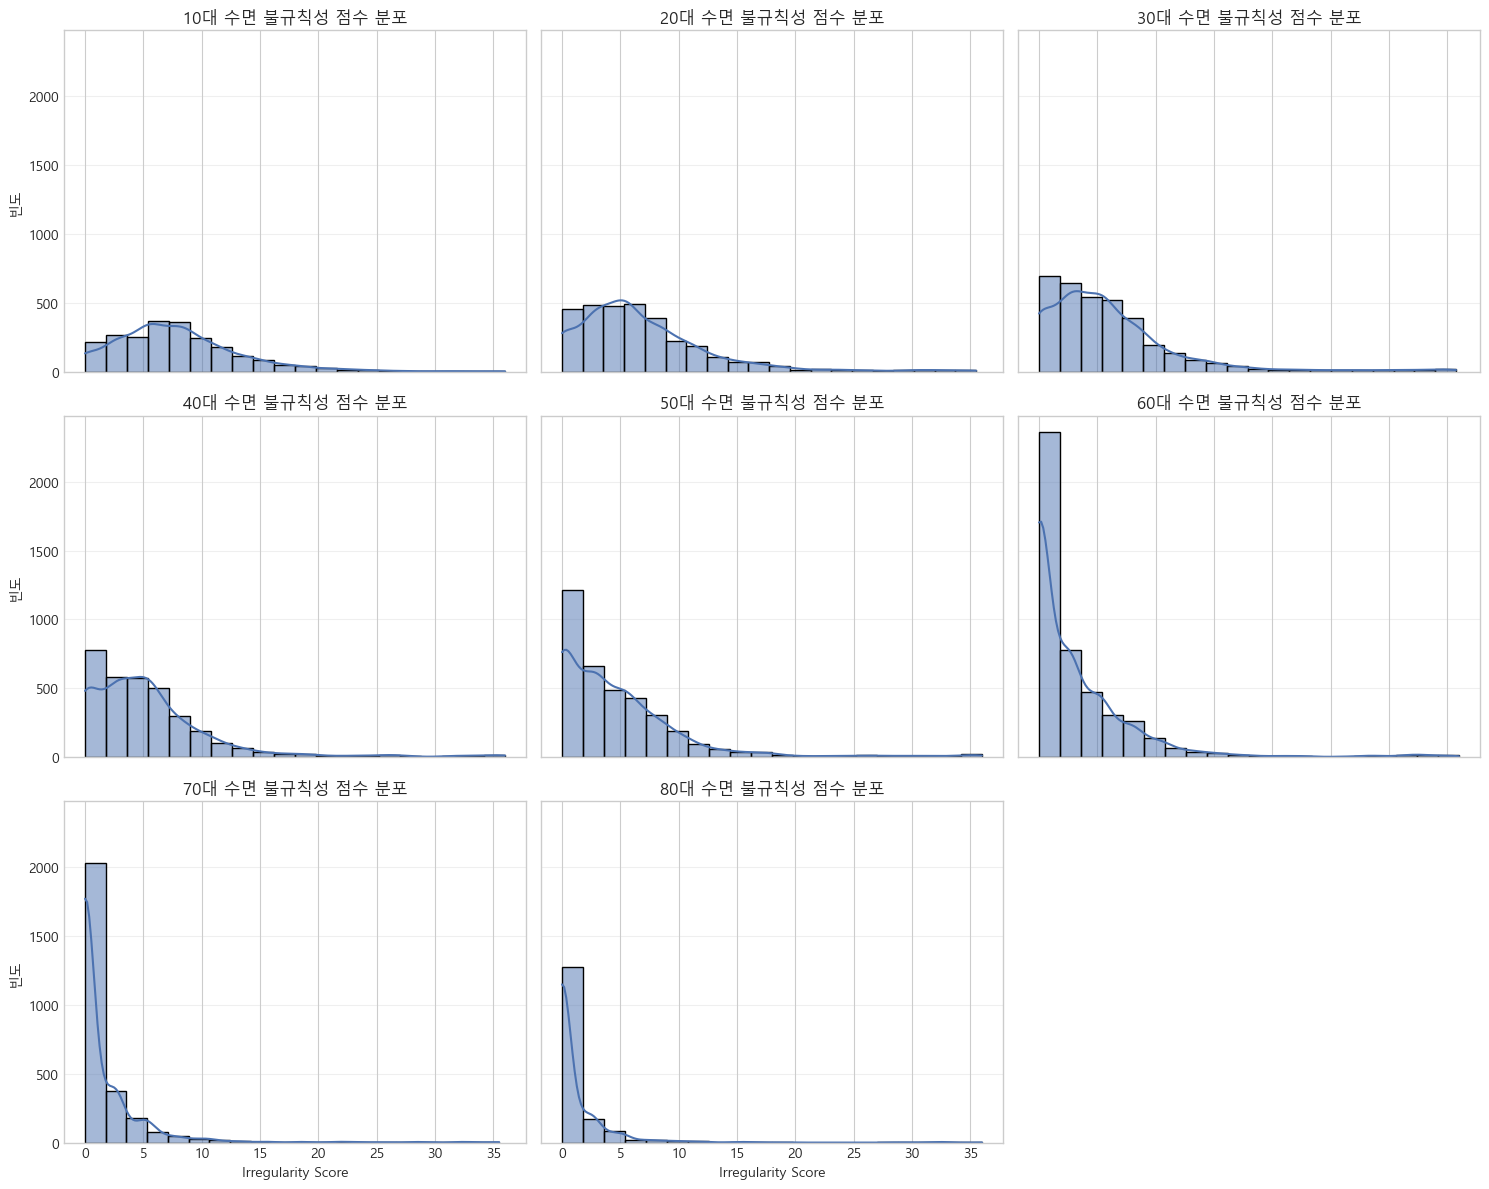

나이대별 평균 지표:
                 Social_Jetlag  Sleep_Catchup  Bedtime_Diff  Wake_Diff  \
AGE_GROUP_LABEL                                                          
10대                       1.98           1.17          1.50       2.60   
20대                       1.73           0.87          1.44       2.10   
30대                       1.48           0.91          1.22       1.83   
40대                       1.34           0.85          1.07       1.71   
50대                       1.15           0.74          0.86       1.50   
60대                       0.75           0.43          0.58       0.96   
70대                       0.36           0.10          0.29       0.44   
80대                       0.25           0.02          0.21       0.30   

                 Irregularity_Score  
AGE_GROUP_LABEL                      
10대                            7.82  
20대                            6.73  
30대                            5.91  
40대                            5.42  
50대                

In [5]:
# 종합 수면 변동성 분석 (SJL + Catch-up + 기상/취침 차이)

import re

# 1. 데이터 준비
TARGET_COLS = ['RIDAGEYR', 'SLQ300', 'SLQ310', 'SLQ320', 'SLQ330']
available_cols = [c for c in TARGET_COLS if c in sleep_final_df.columns]
analysis_df = sleep_final_df[available_cols].dropna().copy()

if all(col in analysis_df.columns for col in TARGET_COLS):
    def time_to_hours(val):
        if pd.isna(val):
            return None
        if isinstance(val, bytes):
            val = val.decode('utf-8')
        val = str(val).strip().upper()
        is_pm = "PM" in val or "오후" in val
        is_am = "AM" in val or "오전" in val
        clean_val = re.sub(r'[^0-9:]', '', val)
        if not clean_val:
            return None
        try:
            if ":" in clean_val:
                h, m = map(int, clean_val.split(':'))
            elif len(clean_val) <= 2:
                h, m = int(clean_val), 0
            else:
                h, m = int(clean_val[:-2]), int(clean_val[-2:])
            if is_pm and h < 12:
                h += 12
            if is_am and h == 12:
                h = 0
            return (h + m / 60.0) % 24
        except:
            return None

    def get_duration(bt, wu):
        return (wu + 24 - bt) if wu < bt else (wu - bt)

    def get_midsleep(bt, duration):
        mid = bt + (duration / 2)
        return mid - 24 if mid >= 24 else mid

    def get_diff(val1, val2):
        diff = val1 - val2
        if diff > 12:
            diff -= 24
        elif diff < -12:
            diff += 24
        return diff

    for col in ['SLQ300', 'SLQ310', 'SLQ320', 'SLQ330']:
        analysis_df[col] = analysis_df[col].apply(time_to_hours)

    analysis_df = analysis_df.dropna()

    # 2. 종합 지표 계산
    analysis_df['Dur_Wkday'] = analysis_df.apply(lambda x: get_duration(x['SLQ300'], x['SLQ310']), axis=1)
    analysis_df['Dur_Wkend'] = analysis_df.apply(lambda x: get_duration(x['SLQ320'], x['SLQ330']), axis=1)
    analysis_df['Mid_Wkday'] = analysis_df.apply(lambda x: get_midsleep(x['SLQ300'], x['Dur_Wkday']), axis=1)
    analysis_df['Mid_Wkend'] = analysis_df.apply(lambda x: get_midsleep(x['SLQ320'], x['Dur_Wkend']), axis=1)

    analysis_df['Social_Jetlag'] = analysis_df.apply(lambda x: abs(get_diff(x['Mid_Wkend'], x['Mid_Wkday'])), axis=1)
    analysis_df['Sleep_Catchup'] = analysis_df['Dur_Wkend'] - analysis_df['Dur_Wkday']
    analysis_df['Bedtime_Diff'] = analysis_df.apply(lambda x: abs(get_diff(x['SLQ320'], x['SLQ300'])), axis=1)
    analysis_df['Wake_Diff'] = analysis_df.apply(lambda x: abs(get_diff(x['SLQ330'], x['SLQ310'])), axis=1)
    analysis_df['Irregularity_Score'] = (
        analysis_df['Social_Jetlag']
        + analysis_df['Sleep_Catchup'].abs()
        + analysis_df['Bedtime_Diff']
        + analysis_df['Wake_Diff']
    )

    analysis_df['AGE_GROUP'] = (analysis_df['RIDAGEYR'] // 10 * 10).astype(int)
    analysis_df['AGE_GROUP_LABEL'] = analysis_df['AGE_GROUP'].apply(lambda x: f"{x}대")

    # 3. 나이대별 종합 점수 분포 시각화
    age_labels = sorted(analysis_df['AGE_GROUP_LABEL'].dropna().unique())
    n_cols = 3
    n_rows = int(np.ceil(len(age_labels) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows), sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)

    for idx, label in enumerate(age_labels):
        ax = axes[idx]
        group_data = analysis_df[analysis_df['AGE_GROUP_LABEL'] == label]
        sns.histplot(data=group_data, x='Irregularity_Score', bins=20, kde=True, color='#4C72B0', ax=ax)
        ax.set_title(f'{label} 수면 불규칙성 점수 분포', fontsize=12)
        ax.set_xlabel('Irregularity Score')
        ax.set_ylabel('빈도')
        ax.grid(axis='y', alpha=0.3)

    # 남는 서브플롯 비활성화
    for j in range(len(age_labels), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    # 4. 나이대별 요약
    stats = analysis_df.groupby('AGE_GROUP_LABEL')[
        ['Social_Jetlag', 'Sleep_Catchup', 'Bedtime_Diff', 'Wake_Diff', 'Irregularity_Score']
    ].mean().round(2)
    print("나이대별 평균 지표:")
    print(stats)
else:
    print("분석에 필요한 컬럼이 데이터셋에 존재하지 않습니다.")

In [6]:
# 종합 불규칙성 점수 백분위(나이대별, 0을 0 퍼센타일로 고정)
required_cols = ['Irregularity_Score']

if all(col in analysis_df.columns for col in required_cols):
    if 'AGE_GROUP_LABEL' not in analysis_df.columns:
        if 'RIDAGEYR' in analysis_df.columns:
            analysis_df['AGE_GROUP'] = (analysis_df['RIDAGEYR'] // 10 * 10).astype(int)
            analysis_df['AGE_GROUP_LABEL'] = analysis_df['AGE_GROUP'].apply(lambda x: f"{x}대")
        else:
            print("나이대 컬럼을 만들 수 없습니다. RIDAGEYR가 필요합니다.")

    if 'AGE_GROUP_LABEL' in analysis_df.columns:
        percentiles = np.arange(0, 101, 10)
        result_frames = []

        for age_label, group_df in analysis_df.groupby('AGE_GROUP_LABEL'):
            irr_values = group_df['Irregularity_Score'].dropna().to_numpy()
            if irr_values.size == 0:
                continue

            irr_values = np.concatenate([irr_values, np.array([0.0])])
            irr_p = np.percentile(irr_values, percentiles)

            percentile_df = pd.DataFrame({
                'AGE_GROUP_LABEL': age_label,
                'Percentile': percentiles,
                'Irregularity_Score': np.round(irr_p, 3)
            })
            result_frames.append(percentile_df)

        if result_frames:
            result_df = pd.concat(result_frames, axis=0, ignore_index=True)
            print("종합 불규칙성 점수 백분위 (나이대별)")
            print(result_df)
        else:
            print("나이대별로 계산할 데이터가 없습니다.")
else:
    print("분석에 필요한 컬럼이 데이터셋에 존재하지 않습니다.")

종합 불규칙성 점수 백분위 (나이대별)
   AGE_GROUP_LABEL  Percentile  Irregularity_Score
0              10대           0                0.00
1              10대          10                2.50
2              10대          20                3.00
3              10대          30                5.00
4              10대          40                5.75
..             ...         ...                 ...
83             80대          60                0.00
84             80대          70                0.00
85             80대          80                2.50
86             80대          90                3.75
87             80대         100               36.00

[88 rows x 3 columns]


### 와이블 분포 적합

c:\Users\user\Documents\Projects_src\DB\.venv\Lib\site-packages\scipy\stats\_continuous_distns.py:2757: RuntimeWarning: divide by zero encountered in power
  return c*pow(x, c-1)*np.exp(-pow(x, c))


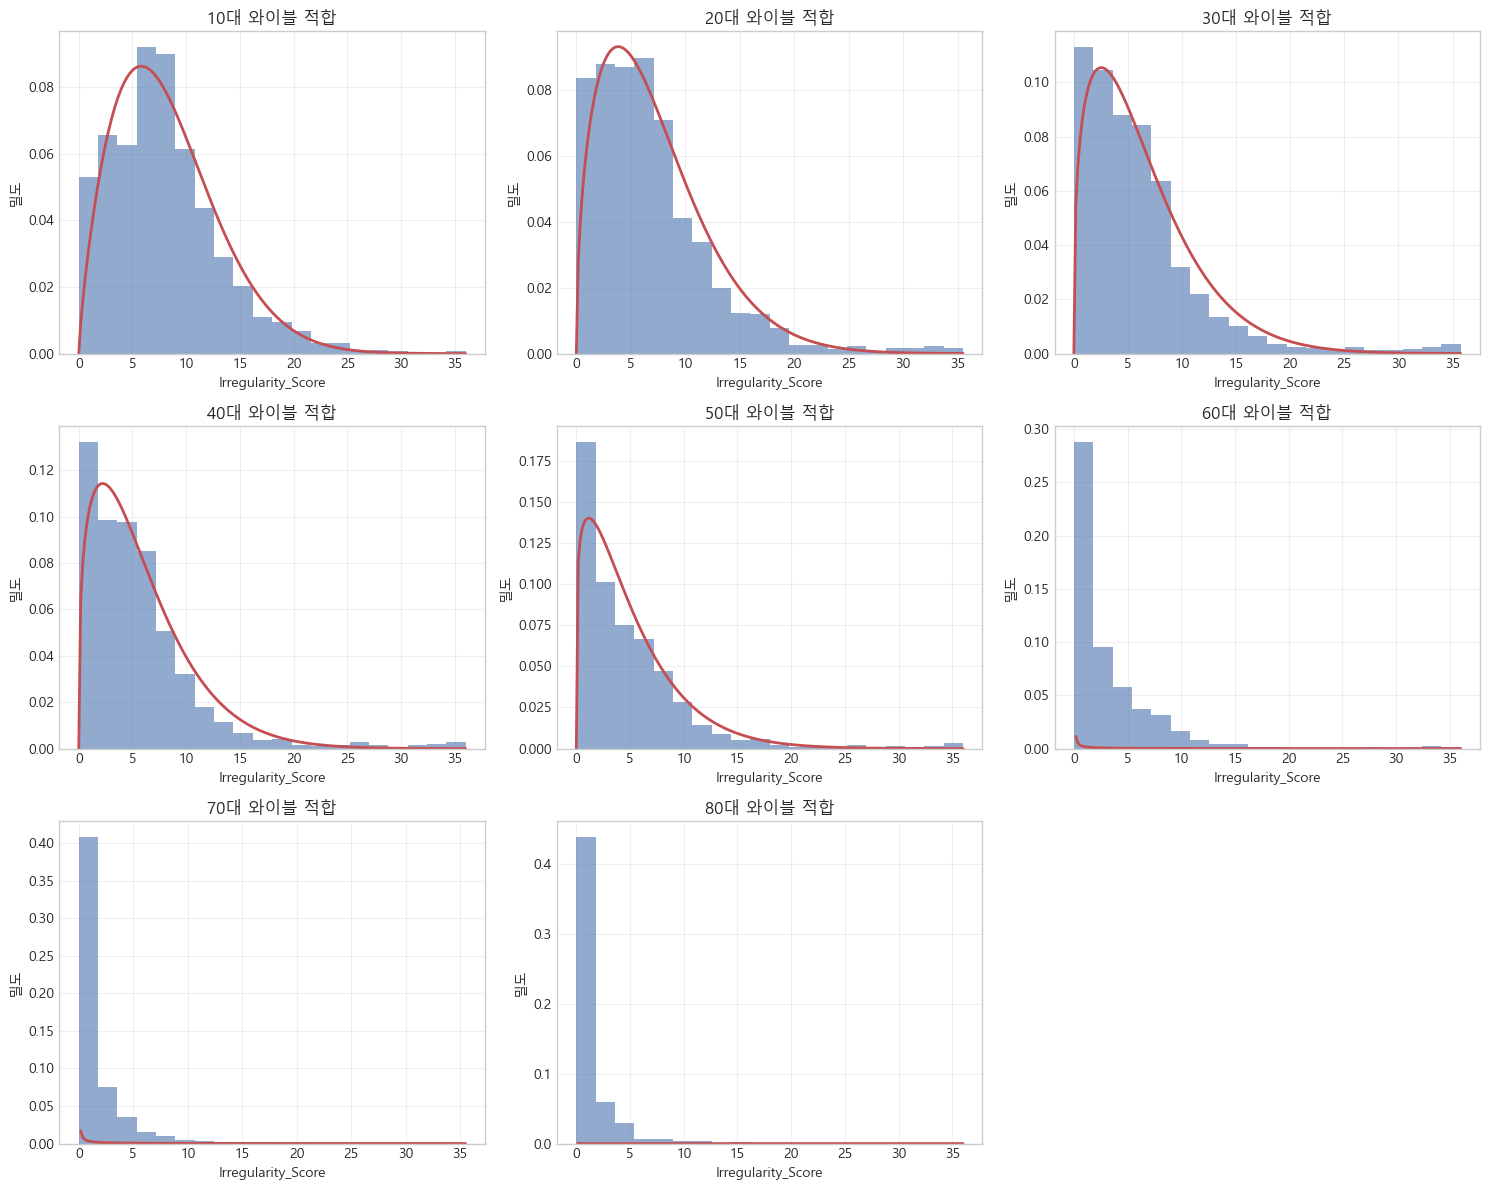

In [7]:
# 나이대별 수면 불규칙성 분포에 와이블 분포(MLE) 적합 및 시각화
try:
    from scipy.stats import weibull_min
except Exception as e:
    raise ImportError("scipy가 필요합니다. 설치 후 다시 실행하세요: pip install scipy") from e

target_col = 'Irregularity_Score'
if target_col in analysis_df.columns and 'AGE_GROUP_LABEL' in analysis_df.columns:
    age_labels = sorted(analysis_df['AGE_GROUP_LABEL'].dropna().unique())
    if not age_labels:
        print("나이대 그룹이 없습니다.")
    else:
        n_cols = 3
        n_rows = int(np.ceil(len(age_labels) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows), sharex=False, sharey=False)
        axes = np.array(axes).reshape(-1)

        for idx, label in enumerate(age_labels):
            ax = axes[idx]
            group_vals = analysis_df.loc[analysis_df['AGE_GROUP_LABEL'] == label, target_col].dropna()
            if group_vals.empty:
                ax.set_title(f"{label} (데이터 없음)")
                ax.axis('off')
                continue

            # MLE로 와이블 분포 적합 (loc=0 고정)
            shape, loc, scale = weibull_min.fit(group_vals.to_numpy(), floc=0)
            x_min, x_max = group_vals.min(), group_vals.max()
            x = np.linspace(x_min, x_max, 200)
            pdf = weibull_min.pdf(x, shape, loc=loc, scale=scale)

            ax.hist(group_vals, bins=20, density=True, alpha=0.6, color='#4C72B0')
            ax.plot(x, pdf, color='#C44E52', linewidth=2)
            ax.set_title(f"{label} 와이블 적합")
            ax.set_xlabel(target_col)
            ax.set_ylabel('밀도')
            ax.grid(alpha=0.3)

        # 남는 서브플롯 비활성화
        for j in range(len(age_labels), len(axes)):
            axes[j].axis('off')

        plt.tight_layout()
        plt.show()
else:
    print("분석에 필요한 컬럼이 없습니다. (Irregularity_Score, AGE_GROUP_LABEL)")

In [8]:
# 나이대별 백분위 테이블 생성 (변동성 0을 0퍼센타일로 포함)
from IPython.display import display

target_col = 'Irregularity_Score'
if target_col in analysis_df.columns and 'AGE_GROUP_LABEL' in analysis_df.columns:
    percentiles = np.arange(0, 101, 10)
    frames = []

    for age_group, group_df in analysis_df.groupby('AGE_GROUP_LABEL'):
        values = group_df[target_col].dropna().to_numpy()
        if values.size == 0:
            continue
        values = np.concatenate([values, np.array([0.0])])
        p_values = np.percentile(values, percentiles)
        frames.append(pd.DataFrame({
            'age_group': age_group,
            'percentile': percentiles,
            'sleep_pattern_at_percentile': np.round(p_values, 3)
        }))

    if frames:
        sleep_pattern_percentile_df = pd.concat(frames, axis=0, ignore_index=True)
        display(sleep_pattern_percentile_df)
    else:
        print("나이대별로 계산할 데이터가 없습니다.")
else:
    print("분석에 필요한 컬럼이 없습니다. (Irregularity_Score, AGE_GROUP_LABEL)")

,age_group,percentile,sleep_pattern_at_percentile
0,10대,0,0.00
1,10대,10,2.50
2,10대,20,3.00
3,10대,30,5.00
4,10대,40,5.75
...,...,...,...
83,80대,60,0.00
84,80대,70,0.00
85,80대,80,2.50
86,80대,90,3.75


In [ ]:
import os
import json
import numpy as np
import pandas as pd

try:
    from scipy.stats import weibull_min
except Exception as e:
    raise ImportError("scipy is required. Install it with: pip install scipy") from e

if "analysis_df" not in globals():
    raise ValueError("analysis_df is missing.")

std_cols = [
    "source_notebook",
    "domain",
    "distribution",
    "age_group",
    "percentile",
    "target_steps",
    "percentile_value",
    "value_column",
    "param_s",
    "param_n",
    "param_p",
    "param_mu",
    "param_shape",
    "param_loc",
    "param_scale",
    "sample_size",
    "fit_method",
    "fit_params",
    "notes",
]

target_col = "Irregularity_Score"
percentiles = np.arange(0, 101, 10)
rows_records = []

if target_col in analysis_df.columns and "AGE_GROUP_LABEL" in analysis_df.columns:
    for age_label, group_df in analysis_df.groupby("AGE_GROUP_LABEL"):
        values = group_df[target_col].dropna().to_numpy()

        if values.size == 0:
            for p in percentiles:
                rows_records.append(
                    {
                        "age_group": age_label,
                        "percentile": int(p),
                        "percentile_value": np.nan,
                        "sample_size": 0,
                        "param_shape": np.nan,
                        "param_loc": np.nan,
                        "param_scale": np.nan,
                    }
                )
            continue

        shape, loc, scale = weibull_min.fit(values, floc=0)
        q = percentiles / 100.0
        p_values = weibull_min.ppf(q, shape, loc=loc, scale=scale)
        p_values = np.where(np.isfinite(p_values), p_values, np.nan)

        for p, pv in zip(percentiles, p_values):
            rows_records.append(
                {
                    "age_group": age_label,
                    "percentile": int(p),
                    "percentile_value": float(np.round(pv, 3)) if np.isfinite(pv) else np.nan,
                    "sample_size": int(values.size),
                    "param_shape": float(shape),
                    "param_loc": float(loc),
                    "param_scale": float(scale),
                }
            )
else:
    raise ValueError("analysis_df must include Irregularity_Score and AGE_GROUP_LABEL columns.")

rows = pd.DataFrame(rows_records)
rows["source_notebook"] = "DB_sleep_pattern.ipynb"
rows["domain"] = "sleep_pattern"
rows["distribution"] = "weibull_min"
rows["target_steps"] = pd.NA
rows["value_column"] = "sleep_pattern_weibull_ppf"
rows["param_s"] = rows["param_shape"]
rows["param_n"] = pd.NA
rows["param_p"] = pd.NA
rows["param_mu"] = pd.NA
rows["fit_method"] = "MLE(weibull_min.fit, floc=0); percentile_value=weibull_min.ppf"
rows["notes"] = "Weibull percentile by age group; p=100 is theoretical inf and stored as NaN"

rows["fit_params"] = rows.apply(
    lambda r: json.dumps(
        {
            "shape": None if pd.isna(r["param_shape"]) else float(r["param_shape"]),
            "loc": None if pd.isna(r["param_loc"]) else float(r["param_loc"]),
            "scale": None if pd.isna(r["param_scale"]) else float(r["param_scale"]),
            "s": None if pd.isna(r["param_s"]) else float(r["param_s"]),
        },
        ensure_ascii=False,
    ),
    axis=1,
)

rows = rows[std_cols]

output_path = "percentile.csv"
if os.path.exists(output_path):
    existing = pd.read_csv(output_path)
else:
    existing = pd.DataFrame(columns=std_cols)

for col in std_cols:
    if col not in existing.columns:
        existing[col] = pd.NA

existing = existing[~((existing["domain"] == "sleep_pattern") & (existing["distribution"] == "weibull_min"))].copy()
result = pd.concat([existing[std_cols], rows], ignore_index=True)
result = result.sort_values(["domain", "distribution", "age_group", "percentile"], kind="stable").reset_index(drop=True)
result.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"Saved percentile table to: {os.path.abspath(output_path)}")
print("sleep_pattern/weibull_min rows written:", len(rows))

Saved percentile table to: c:\Users\user\Documents\Projects_src\DB\percentile.csv
sleep_pattern/weibull_min rows written: 88


C:\Users\user\AppData\Local\Temp\ipykernel_12752\605666255.py:99: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result = pd.concat([existing[std_cols], rows], ignore_index=True)
